<a href="https://colab.research.google.com/github/HaripriyaLogu/SUPPLY-CHAIN-OPTIMIZATION-USING-PREDICTIVE-ANALYTICS/blob/Supply-chain-management/SUPPLY_CHAIN_OPTIMIZATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("/content/shoe_sales.csv")

# ================================
# 3. STANDARDIZE COLUMN NAMES
# ================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# ================================
# 4. DATE HANDLING (FIXED)
# ================================
date_col = "snapshot_date"

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# Drop rows with invalid dates
df = df.dropna(subset=[date_col])

# Sort for time-series modeling
df = df.sort_values(by=date_col).reset_index(drop=True)

# ================================
# 5. REMOVE DUPLICATES
# ================================
df = df.drop_duplicates()

# ================================
# 6. HANDLE MISSING VALUES
# ================================
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# ================================
# 7. ENCODE CATEGORICAL FEATURES
# ================================
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ================================
# 8. TIME FEATURES (SAFE)
# ================================
df["year"] = df[date_col].dt.year
df["month"] = df[date_col].dt.month
df["week"] = df[date_col].dt.isocalendar().week.astype(int)

# ================================
# 9. FINAL VALIDATION
# ================================
print("Final Shape:", df.shape)
print(df.head())
print(df.isnull().sum())


Final Shape: (500, 23)
   product_name  product_type  total_produced  total_sold  damaged_units  \
0            18             3         28818.0     14544.0         7032.0   
1            15             6         85456.0     54857.0        15629.0   
2             8             4         87621.0     61302.0        12741.0   
3            15             1         26691.0     12297.0        13677.0   
4            13             1         22198.0     15630.0         3155.0   

   month  year  edition_type  unit_price  target_gender  ...  \
0      1  2015             3        75.0              1  ...   
1      1  2015             1        80.0              1  ...   
2      1  2015             2        90.0              0  ...   
3      1  2015             4        80.0              1  ...   
4      2  2015             1        35.0              0  ...   

   estimated_revenue  quarter  snapshot_date  price_bucket  \
0          1090800.0        0     2015-01-01             2   
1          

In [ ]:
print(df.columns.tolist())


['product_name', 'product_type', 'total_produced', 'total_sold', 'damaged_units', 'month', 'year', 'edition_type', 'unit_price', 'target_gender', 'sell_through_rate', 'damage_rate', 'unsold_inventory', 'estimated_revenue', 'quarter', 'snapshot_date', 'price_bucket', 'manufacturing_date', 'selling_date', 'performance_score', 'sneaker_grade', 'units_received', 'week']


DATA ANALYSIS


In [ ]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nStatistical Summary:\n")
df.describe()


Shape: (500, 23)

Data Types:
 product_name                   int64
product_type                   int64
total_produced               float64
total_sold                   float64
damaged_units                float64
month                          int32
year                           int32
edition_type                   int64
unit_price                   float64
target_gender                  int64
sell_through_rate              int64
damage_rate                    int64
unsold_inventory             float64
estimated_revenue            float64
quarter                        int64
snapshot_date         datetime64[ns]
price_bucket                   int64
manufacturing_date             int64
selling_date                   int64
performance_score            float64
sneaker_grade                  int64
units_received               float64
week                           int64
dtype: object

Statistical Summary:



,product_name,product_type,total_produced,total_sold,damaged_units,month,year,edition_type,unit_price,target_gender,...,estimated_revenue,quarter,snapshot_date,price_bucket,manufacturing_date,selling_date,performance_score,sneaker_grade,units_received,week
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,...,5.000000e+02,500.000000,500,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,9.500000,3.002000,53757.092000,29288.500000,12631.32800,6.700000,2019.558000,1.966000,86.000000,0.526000,...,2.494873e+06,1.564000,2020-01-12 18:02:52.800000,1.55000,58.730000,235.668000,33.532932,2.00000,53757.092000,26.780000
min,0.000000,0.000000,10191.000000,5035.000000,6.00000,1.000000,2015.000000,0.000000,35.000000,0.000000,...,1.890000e+05,0.000000,2015-01-01 00:00:00,0.00000,0.000000,0.000000,-82.477328,0.00000,10191.000000,1.000000
25%,4.750000,1.000000,30015.000000,12550.750000,2366.00000,4.000000,2017.000000,1.000000,70.000000,0.000000,...,1.011160e+06,1.000000,2017-09-01 00:00:00,1.75000,28.000000,119.750000,3.934180,1.00000,30015.000000,14.000000
50%,9.500000,3.000000,53357.500000,22277.000000,7993.00000,7.000000,2020.000000,2.000000,82.500000,1.000000,...,1.863760e+06,2.000000,2020-02-01 00:00:00,2.00000,57.000000,235.500000,35.499179,2.00000,53357.500000,26.000000
75%,14.250000,5.000000,76635.000000,40691.500000,17290.50000,10.000000,2022.000000,3.000000,100.000000,1.000000,...,3.338479e+06,3.000000,2022-07-01 00:00:00,2.00000,90.000000,353.250000,68.029628,3.00000,76635.000000,40.000000
max,19.000000,6.000000,99922.000000,97181.000000,78238.00000,12.000000,2024.000000,4.000000,140.000000,1.000000,...,1.068991e+07,3.000000,2024-12-01 00:00:00,2.00000,118.000000,467.000000,99.816491,4.00000,99922.000000,53.000000
std,5.772056,2.037228,26087.657543,21573.376256,13908.38519,3.467282,2.812553,1.445345,23.023035,0.499824,...,1.970713e+06,1.131576,NaN,0.80548,35.006571,135.001439,41.316360,1.41563,26087.657543,15.074285


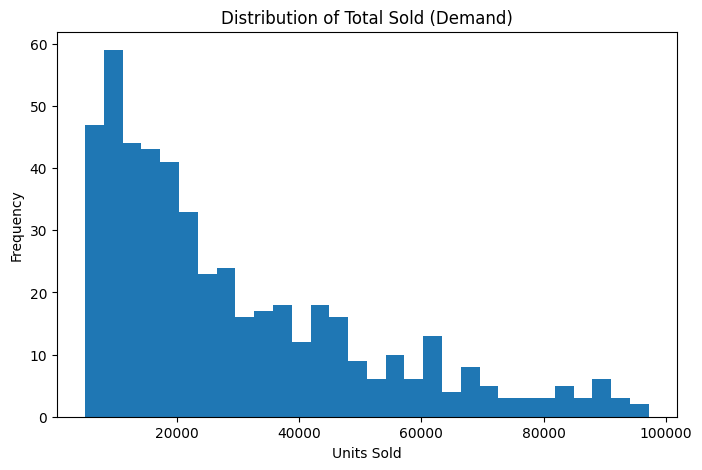

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["total_sold"], bins=30)
plt.title("Distribution of Total Sold (Demand)")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()


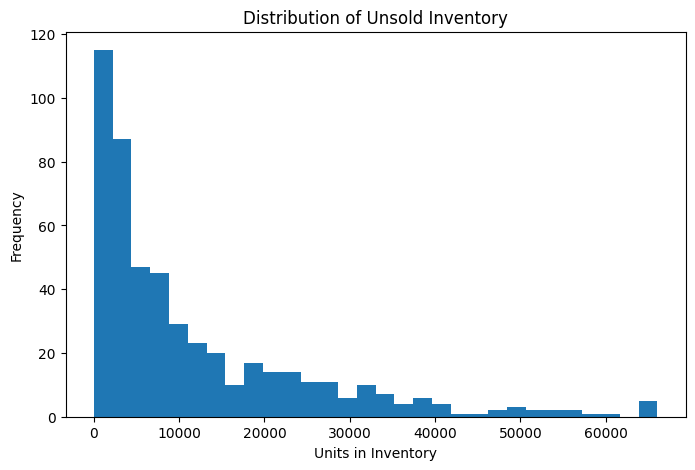

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["unsold_inventory"], bins=30)
plt.title("Distribution of Unsold Inventory")
plt.xlabel("Units in Inventory")
plt.ylabel("Frequency")
plt.show()


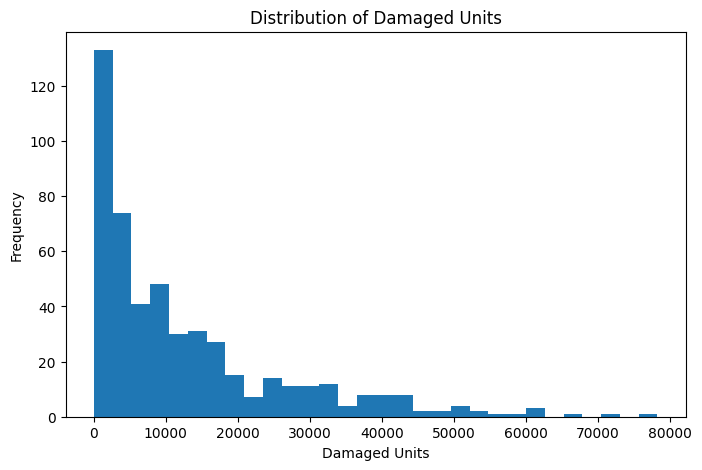

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["damaged_units"], bins=30)
plt.title("Distribution of Damaged Units")
plt.xlabel("Damaged Units")
plt.ylabel("Frequency")
plt.show()


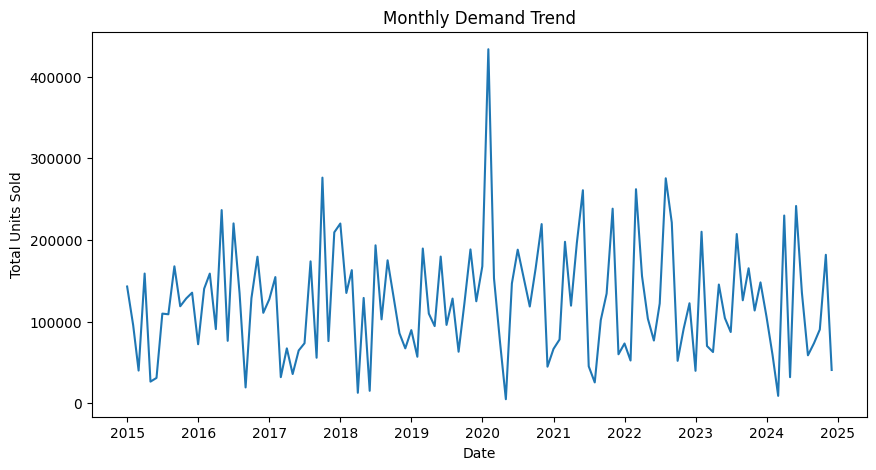

In [ ]:
monthly_demand = (
    df.groupby(["year", "month"])["total_sold"]
    .sum()
    .reset_index()
)

monthly_demand["date"] = pd.to_datetime(
    monthly_demand["year"].astype(str) + "-" +
    monthly_demand["month"].astype(str) + "-01"
)

plt.figure(figsize=(10,5))
plt.plot(monthly_demand["date"], monthly_demand["total_sold"])
plt.title("Monthly Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.show()


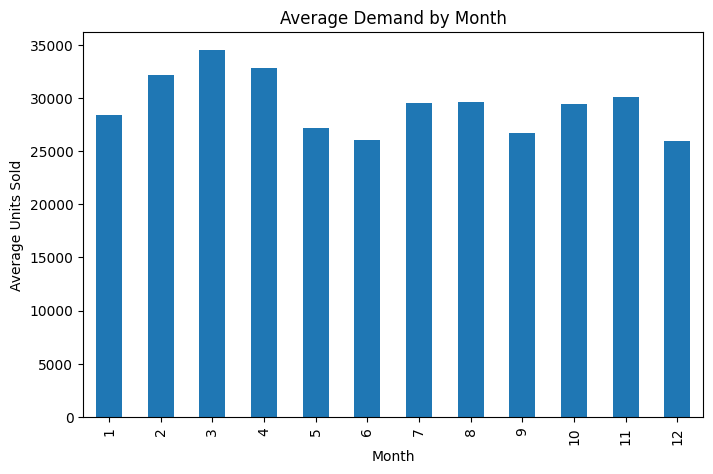

In [ ]:
month_avg = df.groupby("month")["total_sold"].mean()

plt.figure(figsize=(8,5))
month_avg.plot(kind="bar")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.show()


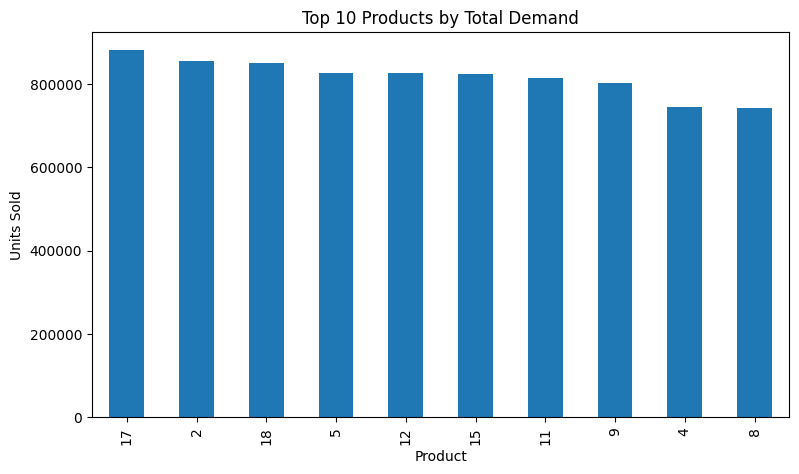

In [ ]:
top_products = (
    df.groupby("product_name")["total_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Total Demand")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.show()


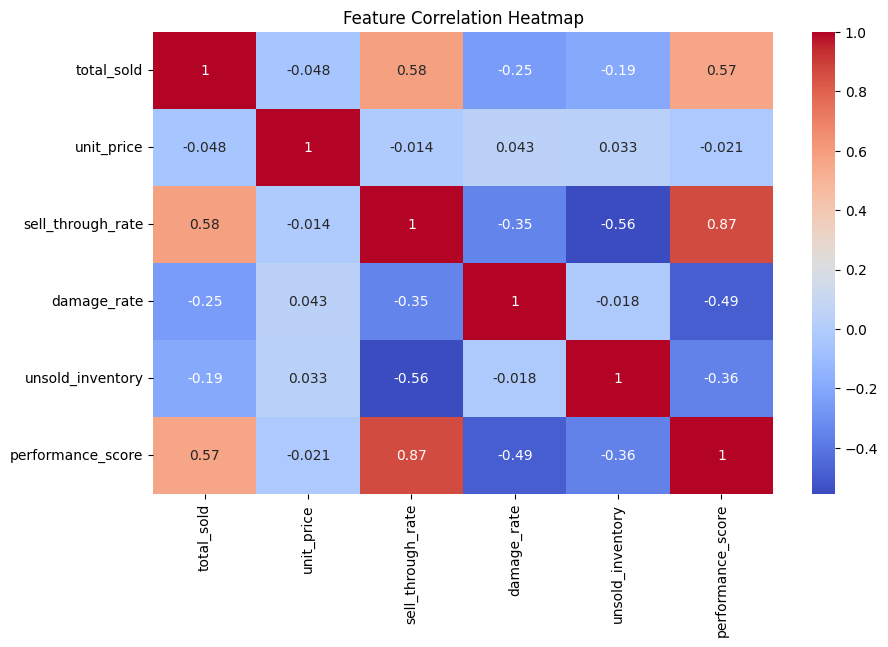

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
corr = df[
    ["total_sold", "unit_price", "sell_through_rate",
     "damage_rate", "unsold_inventory", "performance_score"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


FEATURE ENGINEERING


In [ ]:
# Target variable (Demand)
TARGET = "total_sold"

# Time column
DATE_COL = "snapshot_date"


In [ ]:
# Columns to drop (leakage / not useful for forecasting)
drop_cols = [
    "estimated_revenue",     # derived from sales
    "sell_through_rate",     # depends on sold & inventory
    "damage_rate",           # derived metric
]

df = df.drop(columns=drop_cols, errors="ignore")


In [ ]:
df = df.sort_values(by=["product_name", DATE_COL]).reset_index(drop=True)


In [ ]:
LAGS = [1, 2, 3, 6]  # months

for lag in LAGS:
    df[f"lag_{lag}"] = (
        df.groupby("product_name")[TARGET]
        .shift(lag)
    )


In [ ]:
WINDOWS = [3, 6]

for window in WINDOWS:
    df[f"rolling_mean_{window}"] = (
        df.groupby("product_name")[TARGET]
        .shift(1)
        .rolling(window)
        .mean()
    )

    df[f"rolling_std_{window}"] = (
        df.groupby("product_name")[TARGET]
        .shift(1)
        .rolling(window)
        .std()
    )


In [ ]:
df = df.dropna().reset_index(drop=True)


In [ ]:
FEATURES = [
    # Product & categorical
    "product_name",
    "product_type",
    "edition_type",
    "target_gender",
    "price_bucket",
    "sneaker_grade",

    # Time features
    "year",
    "month",
    "quarter",

    # Inventory & operations
    "total_produced",
    "units_received",
    "unsold_inventory",
    "damaged_units",
    "unit_price",
    "performance_score",

    # Lag features
    "lag_1", "lag_2", "lag_3", "lag_6",

    # Rolling features
    "rolling_mean_3", "rolling_std_3",
    "rolling_mean_6", "rolling_std_6",
]

X = df[FEATURES]
y = df[TARGET]


In [ ]:
print("Final Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nSample Features:")
print(X.head())

print("\nTarget Sample:")
print(y.head())


Final Feature Matrix Shape: (380, 23)
Target Shape: (380,)

Sample Features:
   product_name  product_type  edition_type  target_gender  price_bucket  \
0             0             2             0              0             2   
1             0             1             0              0             2   
2             0             6             3              1             2   
3             0             1             4              0             2   
4             0             4             1              0             2   

   sneaker_grade  year  month  quarter  total_produced  ...  unit_price  \
0              2  2018      1        0         80206.0  ...       100.0   
1              1  2018      2        0         41775.0  ...       100.0   
2              2  2018      5        1         10336.0  ...       100.0   
3              3  2018      7        2         87354.0  ...       100.0   
4              4  2019      5        1         71621.0  ...       100.0   

   performance_

DATA SPLIT


In [ ]:
print("Date Range:")
print(df[DATE_COL].min(), "→", df[DATE_COL].max())


Date Range:
2016-07-01 00:00:00 → 2024-12-01 00:00:00


In [ ]:
# Determine split date (last 6 months)
split_date = df[DATE_COL].max() - pd.DateOffset(months=6)

print("Train data up to:", split_date)
print("Test data after:", split_date)


Train data up to: 2024-06-01 00:00:00
Test data after: 2024-06-01 00:00:00


In [ ]:
# Train set (past)
train_df = df[df[DATE_COL] <= split_date]

# Test set (future)
test_df = df[df[DATE_COL] > split_date]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


Train Shape: (356, 28)
Test Shape: (24, 28)


In [ ]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (356, 23)
y_train: (356,)
X_test: (24, 23)
y_test: (24,)


In [ ]:
# Ensure no future dates in training
assert train_df[DATE_COL].max() < test_df[DATE_COL].min()

print("✅ Time-series split verified. No data leakage.")


✅ Time-series split verified. No data leakage.


DATA MODEL - XGBOOST


In [ ]:
!pip install xgboost


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)


In [ ]:
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")


RMSE : 3748.30
MAE  : 2649.63
MAPE : 24.88%


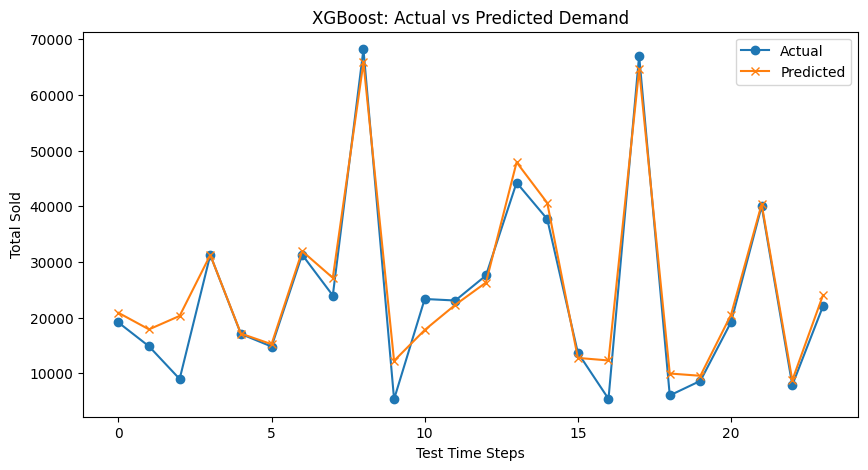

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", marker="o")
plt.plot(y_pred, label="Predicted", marker="x")
plt.title("XGBoost: Actual vs Predicted Demand")
plt.xlabel("Test Time Steps")
plt.ylabel("Total Sold")
plt.legend()
plt.show()


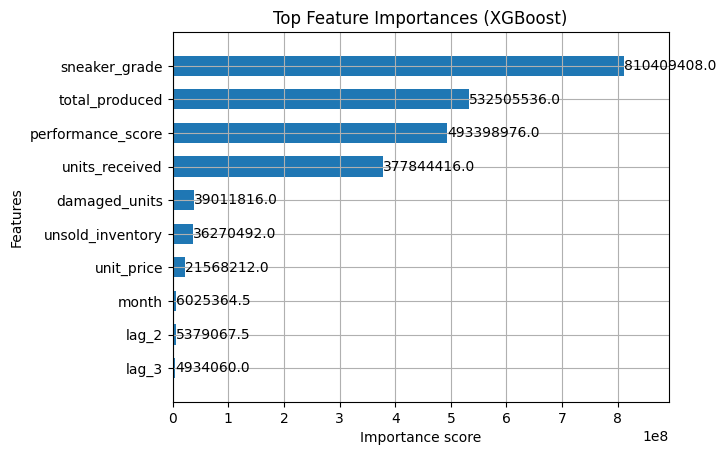

In [ ]:
xgb.plot_importance(
    xgb_model,
    max_num_features=10,
    importance_type="gain",
    height=0.6
)
plt.title("Top Feature Importances (XGBoost)")
plt.show()


DATA-MODEL - LSTM

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt


In [ ]:
lstm_df = df[
    [
        "product_name",
        "snapshot_date",
        "total_sold",
        "unsold_inventory",
        "units_received"
    ]
].copy()


In [ ]:
lstm_df = lstm_df.sort_values(
    ["product_name", "snapshot_date"]
).reset_index(drop=True)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

lstm_df[["unsold_inventory", "units_received"]] = x_scaler.fit_transform(
    lstm_df[["unsold_inventory", "units_received"]]
)

lstm_df[["total_sold"]] = y_scaler.fit_transform(
    lstm_df[["total_sold"]]
)


In [ ]:
import numpy as np

SEQ_LEN = 6

def create_sequences_per_product(data, seq_len):
    X, y = [], []

    for product in data["product_name"].unique():
        product_data = data[data["product_name"] == product]

        values = product_data.values[:, 2:]  # exclude product & date

        if len(values) <= seq_len:
            continue

        for i in range(seq_len, len(values)):
            X.append(values[i-seq_len:i])
            y.append(values[i, 0])  # total_sold

    return np.array(X), np.array(y)

X_all, y_all = create_sequences_per_product(lstm_df, SEQ_LEN)

print("All sequences:", X_all.shape, y_all.shape)


All sequences: (260, 6, 3) (260,)


In [ ]:
# Explicitly force numeric dtype in LSTM features
numeric_cols = ["total_sold", "unsold_inventory", "units_received"]

lstm_df[numeric_cols] = lstm_df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Drop any rows that became NaN
lstm_df = lstm_df.dropna().reset_index(drop=True)


In [ ]:
import numpy as np

def create_sequences_per_product(data, seq_len):
    X, y = [], []

    for product in data["product_name"].unique():
        product_data = data[data["product_name"] == product]

        # Use .loc and .to_numpy() with dtype
        values = product_data.loc[
            :, ["total_sold", "unsold_inventory", "units_received"]
        ].to_numpy(dtype=np.float32)

        if len(values) <= seq_len:
            continue

        for i in range(seq_len, len(values)):
            X.append(values[i-seq_len:i])
            y.append(values[i, 0])  # total_sold

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


In [ ]:
X_all, y_all = create_sequences_per_product(lstm_df, SEQ_LEN)

split_index = int(len(X_all) * 0.8)

X_train_lstm = X_all[:split_index]
y_train_lstm = y_all[:split_index]

X_test_lstm = X_all[split_index:]
y_test_lstm = y_all[split_index:]


In [ ]:
print(X_train_lstm.dtype)
print(X_test_lstm.dtype)
print(y_train_lstm.dtype)
print(y_test_lstm.dtype)


float32
float32
float32
float32


In [ ]:
##################################################################

split_index = int(len(X_all) * 0.8)

X_train_lstm = X_all[:split_index]
y_train_lstm = y_all[:split_index]

X_test_lstm = X_all[split_index:]
y_test_lstm = y_all[split_index:]

print("Train:", X_train_lstm.shape, y_train_lstm.shape)
print("Test :", X_test_lstm.shape, y_test_lstm.shape)


Train: (208, 6, 3) (208,)
Test : (52, 6, 3) (52,)


lstm implementation

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_pred_lstm = model.predict(X_test_lstm).flatten()


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.1039 - val_loss: 0.0607
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0677 - val_loss: 0.0634
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0673 - val_loss: 0.0586
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0660 - val_loss: 0.0579
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0625 - val_loss: 0.0577
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0819 - val_loss: 0.0574
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0602 - val_loss: 0.0571
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0716 - val_loss: 0.0578
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0568 - val_loss: 0.0570
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0669 - val_loss: 0.0568
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0551 - val_loss: 0.0565
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

In [ ]:
y_pred_lstm = model.predict(X_test_lstm).flatten()

y_test_inv = y_scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
y_pred_inv = y_scaler.inverse_transform(y_pred_lstm.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print(rmse,"," ,mae,"," ,mape)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
23923.443230438214 , 19283.875 , 96.30106


HYPERTUNNING XGBOOST

In [ ]:
import xgboost as xgb
import numpy as np

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, make_scorer


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)


In [ ]:
xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


In [ ]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5, 7]
}


In [ ]:
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)


In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,               # Efficient & sufficient
    scoring=rmse_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8,
                                                             0.9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [200, 300, 400, 500],
                                        'subsample': [0.6, 0.7, 0.8, 0.9]},
                   random_state=42,
                   scoring=make_scorer(<lambda>, greater_is_better=False, response_method='predict'),
                   verbose=2)

In [ ]:
print("Best Parameters Found:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)


Best Parameters Found:
{'subsample': 0.6, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV RMSE:
4845.698159842409


In [ ]:
best_xgb_model = xgb.XGBRegressor(
    **random_search.best_params_,
    objective="reg:squarederror",
    random_state=42
)

best_xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_tuned = best_xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae = np.mean(np.abs(y_test - y_pred_tuned))
mape = np.mean(np.abs((y_test - y_pred_tuned) / y_test)) * 100

print(f"Tuned XGBoost RMSE : {rmse:.2f}")
print(f"Tuned XGBoost MAE  : {mae:.2f}")
print(f"Tuned XGBoost MAPE : {mape:.2f}%")


Tuned XGBoost RMSE : 2409.34
Tuned XGBoost MAE  : 1759.40
Tuned XGBoost MAPE : 15.98%


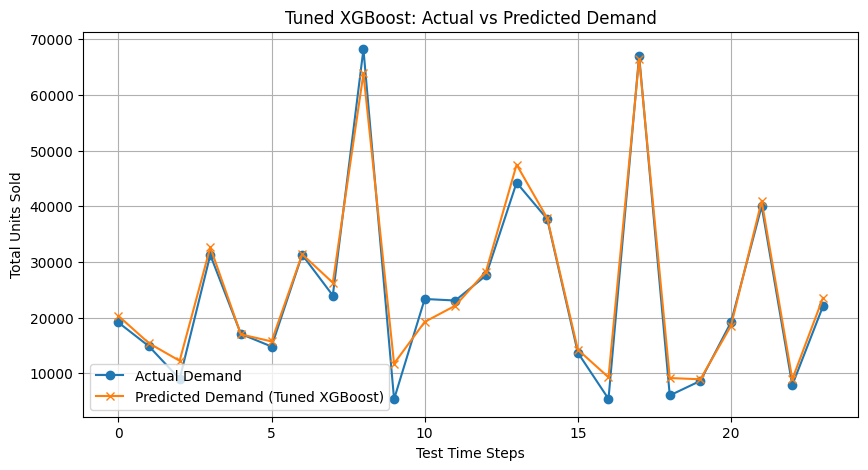

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual Demand", marker="o")
plt.plot(y_pred_tuned, label="Predicted Demand (Tuned XGBoost)", marker="x")

plt.title("Tuned XGBoost: Actual vs Predicted Demand")
plt.xlabel("Test Time Steps")
plt.ylabel("Total Units Sold")
plt.legend()
plt.grid(True)
plt.show()


DEMAND PREDICTION

In [ ]:
# Last snapshot per product
last_df = (
    df.sort_values(["product_name", DATE_COL])
      .groupby("product_name")
      .tail(1)
      .reset_index(drop=True)
)

last_df[[DATE_COL, TARGET, "lag_1", "lag_2", "lag_3", "lag_6"]].head()


,snapshot_date,total_sold,lag_1,lag_2,lag_3,lag_6
0,2024-11-01,19120.0,8752.0,19957.0,28324.0,17458.0
1,2024-08-01,14835.0,12698.0,88719.0,42624.0,15509.0
2,2024-12-01,8969.0,8378.0,21270.0,8478.0,8552.0
3,2024-10-01,31255.0,49245.0,40272.0,43715.0,17245.0
4,2024-04-01,54197.0,24644.0,43777.0,71784.0,20915.0


In [ ]:
def create_future_row(row, next_date):
    new_row = row.copy()

    # Update date features
    new_row[DATE_COL] = next_date
    new_row["year"] = next_date.year
    new_row["month"] = next_date.month
    new_row["quarter"] = (next_date.month - 1) // 3 + 1

    # Shift lag features
    new_row["lag_6"] = new_row["lag_5"] if "lag_5" in new_row else new_row["lag_3"]
    new_row["lag_3"] = new_row["lag_2"]
    new_row["lag_2"] = new_row["lag_1"]
    new_row["lag_1"] = new_row[TARGET]

    return new_row


In [ ]:
from pandas.tseries.offsets import DateOffset

future_forecasts = []

for product in last_df["product_name"].unique():

    product_row = last_df[last_df["product_name"] == product].iloc[0].copy()

    for step in range(1, 7):
        next_date = product_row[DATE_COL] + DateOffset(months=1)

        # Create future feature row
        future_row = create_future_row(product_row, next_date)

        # Prepare features
        X_future = future_row[FEATURES].values.reshape(1, -1)

        # Predict demand
        predicted_demand = best_xgb_model.predict(X_future)[0]

        # Save result
        future_forecasts.append({
            "product_name": product,
            "forecast_month": next_date,
            "predicted_demand": predicted_demand
        })

        # Update row for next iteration
        product_row[TARGET] = predicted_demand
        product_row[DATE_COL] = next_date
        product_row["lag_1"] = predicted_demand



In [ ]:
forecast_df = pd.DataFrame(future_forecasts)

forecast_df.head(10)


,product_name,forecast_month,predicted_demand
0,0,2024-12-01,20057.271484
1,0,2025-01-01,20278.119141
2,0,2025-02-01,20278.119141
3,0,2025-03-01,20278.119141
4,0,2025-04-01,20278.119141
5,0,2025-05-01,20284.044922
6,1,2024-09-01,15771.894531
7,1,2024-10-01,15782.296875
8,1,2024-11-01,15782.296875
9,1,2024-12-01,15844.473633


In [ ]:
# Latest inventory snapshot per product
inventory_df = (
    df.sort_values(["product_name", DATE_COL])
      .groupby("product_name")
      .tail(1)
      .reset_index(drop=True)
)

inventory_df = inventory_df[
    ["product_name", "unsold_inventory", "units_received"]
].rename(columns={
    "unsold_inventory": "current_inventory",
    "units_received": "last_received_units"
})

inventory_df.head()


,product_name,current_inventory,last_received_units
0,0,3872.0,24089.0
1,1,33634.0,60197.0
2,2,19506.0,93753.0
3,3,3786.0,36174.0
4,4,24048.0,81568.0


In [ ]:
forecast_summary = (
    forecast_df.groupby("product_name")["predicted_demand"]
    .agg(["mean", "std", "sum"])
    .reset_index()
)

forecast_summary.columns = [
    "product_name",
    "avg_monthly_demand",
    "demand_std",
    "six_month_demand"
]

forecast_summary.head()


,product_name,avg_monthly_demand,demand_std,six_month_demand
0,0,20242.298828,90.675499,121453.796875
1,1,15879.668945,133.699631,95278.015625
2,2,12948.026367,76.161789,77688.156250
3,3,32784.492188,88.717506,196706.953125
4,4,54765.542969,60.775093,328593.250000


In [ ]:
Z = 1.65          # 95% service level
LEAD_TIME = 1    # 1 month

forecast_summary["safety_stock"] = (
    Z * forecast_summary["demand_std"] * np.sqrt(LEAD_TIME)
)


In [ ]:
forecast_summary["reorder_point"] = (
    forecast_summary["avg_monthly_demand"] * LEAD_TIME
    + forecast_summary["safety_stock"]
)


In [ ]:
inventory_plan = forecast_summary.merge(
    inventory_df,
    on="product_name",
    how="left"
)


In [ ]:
inventory_plan["stock_gap"] = (
    inventory_plan["reorder_point"]
    - inventory_plan["current_inventory"]
)


In [ ]:
REPLENISHMENT_COVERAGE = 2  # months

inventory_plan["recommended_order_qty"] = np.where(
    inventory_plan["stock_gap"] > 0,
    inventory_plan["avg_monthly_demand"] * REPLENISHMENT_COVERAGE
    - inventory_plan["current_inventory"],
    0
)

# No negative orders
inventory_plan["recommended_order_qty"] = (
    inventory_plan["recommended_order_qty"]
    .clip(lower=0)
    .round()
)


In [ ]:
inventory_plan["order_required"] = np.where(
    inventory_plan["current_inventory"]
    <= inventory_plan["reorder_point"],
    "YES",
    "NO"
)


In [ ]:
final_inventory_plan = inventory_plan[
    [
        "product_name",
        "current_inventory",
        "avg_monthly_demand",
        "safety_stock",
        "reorder_point",
        "recommended_order_qty",
        "order_required"
    ]
].sort_values("order_required", ascending=False)

final_inventory_plan.head(10)


,product_name,current_inventory,avg_monthly_demand,safety_stock,reorder_point,recommended_order_qty,order_required
0,0,3872.0,20242.298828,149.614578,20391.914062,36613.0,YES
8,8,14599.0,26406.328125,48.344582,26454.671875,38214.0,YES
18,18,1154.0,85679.351562,296.652618,85976.007812,170205.0,YES
17,17,3597.0,8914.720703,283.103180,9197.824219,14232.0,YES
16,16,3761.0,10578.046875,298.710571,10876.757812,17395.0,YES
14,14,9494.0,66640.398438,207.077423,66847.476562,123787.0,YES
12,12,4235.0,37750.660156,26.059698,37776.718750,71266.0,YES
11,11,6794.0,28916.923828,37.922920,28954.847656,51040.0,YES
10,10,8088.0,19052.560547,65.752159,19118.312500,30017.0,YES
7,7,238.0,31386.625000,105.702332,31492.328125,62535.0,YES


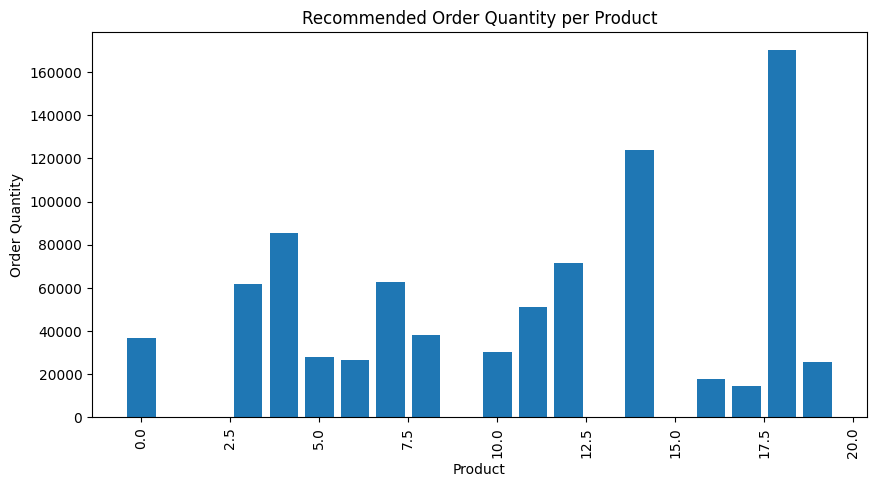

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(
    final_inventory_plan["product_name"],
    final_inventory_plan["recommended_order_qty"]
)

plt.title("Recommended Order Quantity per Product")
plt.xlabel("Product")
plt.ylabel("Order Quantity")
plt.xticks(rotation=90)
plt.show()
